<a href="https://colab.research.google.com/github/sarayuvenkatesh-ux/analytics-sandbox/blob/main/Geely_Auto_Assignment_Linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
car=pd.read_csv('CarPrice_Assignment.csv')

In [ ]:
car.head()


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
print(f"Shape: {car.shape}")

Shape: (205, 26)


In [ ]:
car.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [ ]:
car.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [ ]:
carname=car['CarName']
carname

,CarName
0,alfa-romero giulia
1,alfa-romero stelvio
2,alfa-romero Quadrifoglio
3,audi 100 ls
4,audi 100ls
...,...
200,volvo 145e (sw)
201,volvo 144ea
202,volvo 244dl
203,volvo 246


In [ ]:
# Pick only the text (object) columns
cat_cols = car.select_dtypes(include='object').columns
print("Text columns:", list(cat_cols))
print()

# For each text column, show the unique values and count
for col in cat_cols:
    print(f"--- {col} ({car[col].nunique()} unique values) ---")
    print(car[col].value_counts().to_string())
    print()

Text columns: ['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']

--- CarName (147 unique values) ---
CarName
peugeot 504                        6
toyota corolla                     6
toyota corona                      6
subaru dl                          4
mitsubishi outlander               3
mazda 626                          3
honda civic                        3
mitsubishi mirage g4               3
mitsubishi g4                      3
toyota mark ii                     3
nissan clipper                     2
honda civic cvcc                   2
honda accord                       2
mazda glc                          2
mazda rx-7 gs                      2
mazda glc deluxe                   2
bmw x3                             2
bmw 320i                           2
audi 100ls                         2
volvo 264gl                        2
volvo 144ea                        2
volvo 244dl            

In [ ]:
# Extracting car Company name
car['carCompany'] = car['CarName'].str.split().str[0].str.lower()

# Verify: see all unique company names we extracted
print("Unique companies found:")
print(sorted(car['carCompany'].unique()))

Unique companies found:
['alfa-romero', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'maxda', 'mazda', 'mercury', 'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porcshce', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'toyouta', 'vokswagen', 'volkswagen', 'volvo', 'vw']


In [ ]:
# Correct the typos
car['carCompany'] = car['carCompany'].replace({ 'maxda' : 'mazda', 'porcshce' : 'porsche', 'toyouta' : 'toyota', 'vokswagen' : 'volkswagen', 'vw' : 'volkswagen', })

# Verify company names

print("After fixing — unique companies:", car['carCompany'].nunique())
print(sorted(car['carCompany'].unique()))

After fixing — unique companies: 22
['alfa-romero', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'mazda', 'mercury', 'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'volkswagen', 'volvo']


In [ ]:
# Drop the columns we no longer need
car.drop(['car_ID', 'CarName'], axis=1, inplace=True, errors='ignore')
# Confirm the shape
print("New shape:", car.shape)
print("Columns remaining:", list(car.columns))

New shape: (205, 25)
Columns remaining: ['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price', 'carCompany']


In [ ]:
# Count how many duplicate rows exist
print("Duplicate rows:", car.duplicated().sum())

# Remove them

car.drop_duplicates(inplace=True)

# Confirm shape after removal

print("Shape after removing duplicates:", car.shape)

Duplicate rows: 0
Shape after removing duplicates: (205, 25)


In [ ]:
# Count missing values in each column
missing = car.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])

print(f"\nTotal missing values: {car.isnull().sum().sum()}")

Missing values per column:
Series([], dtype: int64)

Total missing values: 0


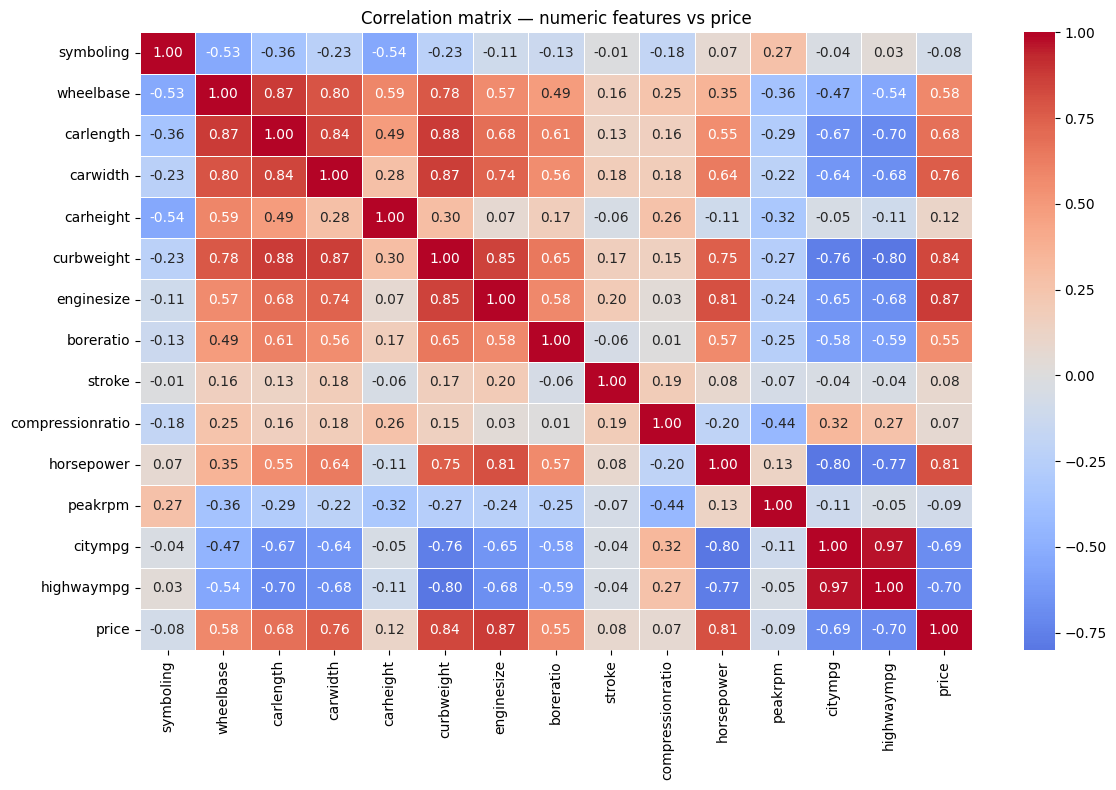


Correlation with price (sorted):
price               1.000
enginesize          0.874
curbweight          0.835
horsepower          0.808
carwidth            0.759
carlength           0.683
wheelbase           0.578
boreratio           0.553
carheight           0.119
stroke              0.079
compressionratio    0.068
symboling          -0.080
peakrpm            -0.085
citympg            -0.686
highwaympg         -0.698
Name: price, dtype: float64


In [ ]:
import seaborn as sns # Added to resolve NameError

# ── Correlation heatmap
plt.figure(figsize=(12, 8))

# Select only numeric columns for correlation
num_cols = car.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = num_cols.corr()

# Draw the heatmap
sns.heatmap(corr_matrix,
           annot=True,       # show the numbers inside each cell
           fmt='.2f',        # round to 2 decimal places
           cmap='coolwarm',  # red = positive, blue = negative
           center=0,
           linewidths=0.5)

plt.title('Correlation matrix — numeric features vs price')
plt.tight_layout()
plt.show()

# Print just the correlation with price, sorted highest to lowest
print("\nCorrelation with price (sorted):")
print(corr_matrix['price'].sort_values(ascending=False).round(3))

### From the heatmap we see that enginesize, curbweight, horsepower, and carwidth show strong positive correlation with price.

###citympg and highwaympg are negatively correlated — fuel-efficient economy cars tend to be cheaper

/tmp/ipykernel_3068/2596795021.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=car[col], y=car['price'],
/tmp/ipykernel_3068/2596795021.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=car[col], y=car['price'],
/tmp/ipykernel_3068/2596795021.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=car[col], y=car['price'],
/tmp/ipykernel_3068/2596795021.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same

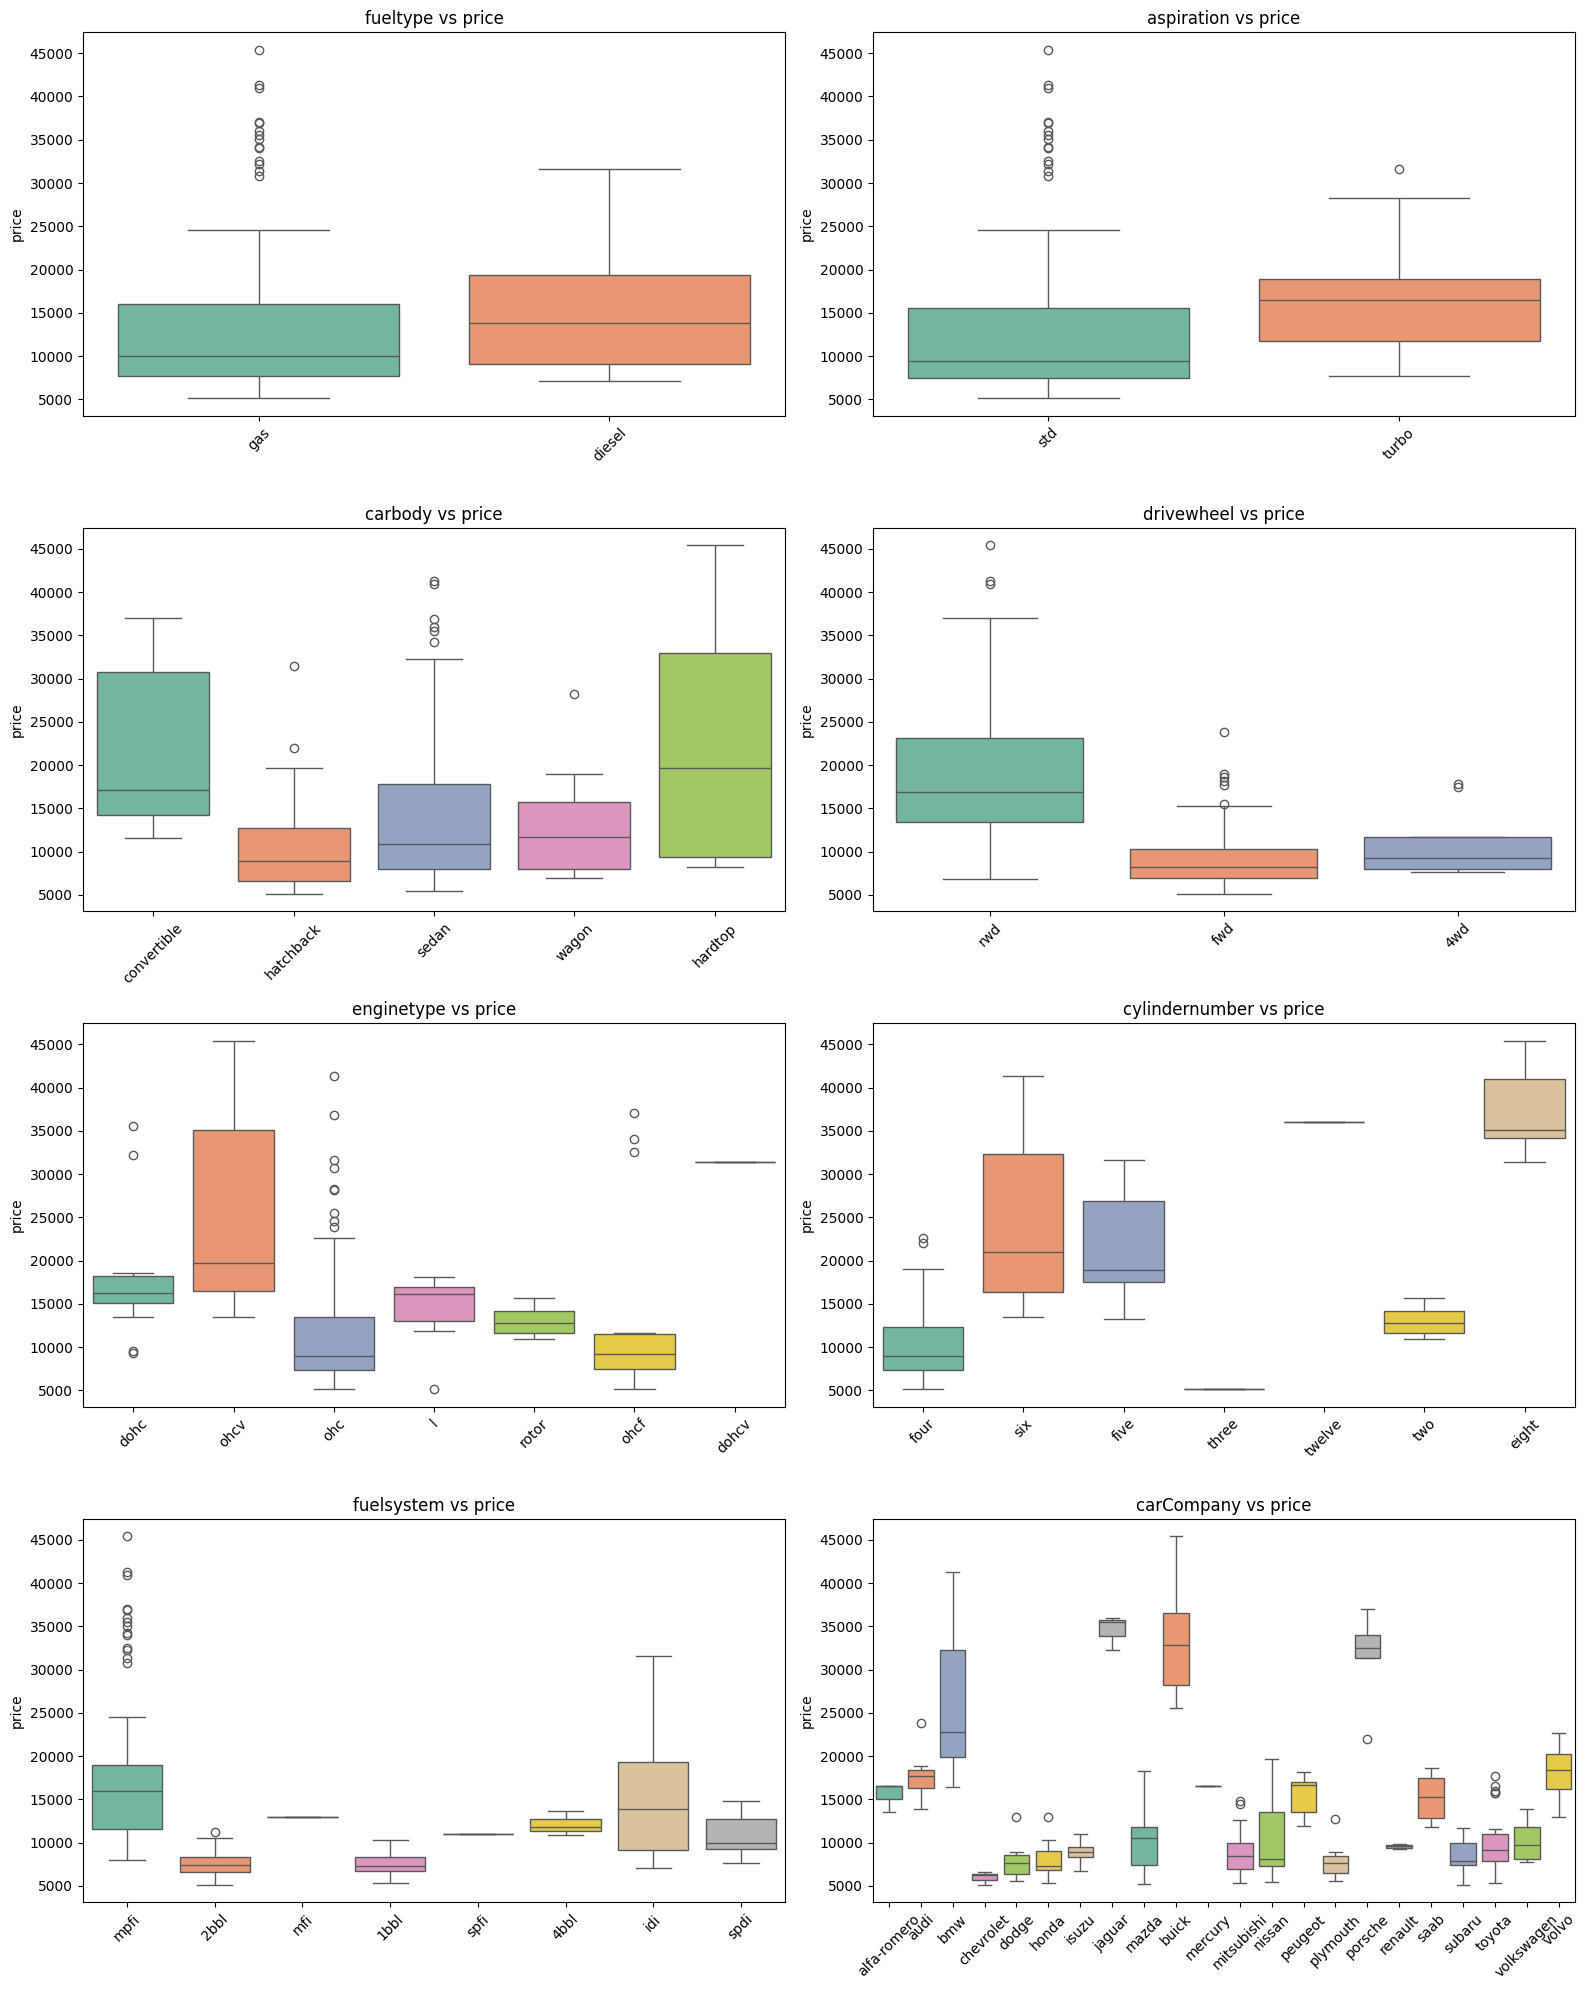

In [ ]:
# Categorical features vs price (boxplots)
cat_features = ['fueltype', 'aspiration', 'carbody',
                'drivewheel', 'enginetype', 'cylindernumber',
                'fuelsystem', 'carCompany']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()   # turn 2D grid into a simple list

for i, col in enumerate(cat_features):
    sns.boxplot(x=car[col], y=car['price'],
                ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs price')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## From the above we infer that: Rear-wheel drive, turbo aspiration, higher cylinder counts, and luxury brands (jaguar, porsche, bmw) are associated with significantly higher prices.

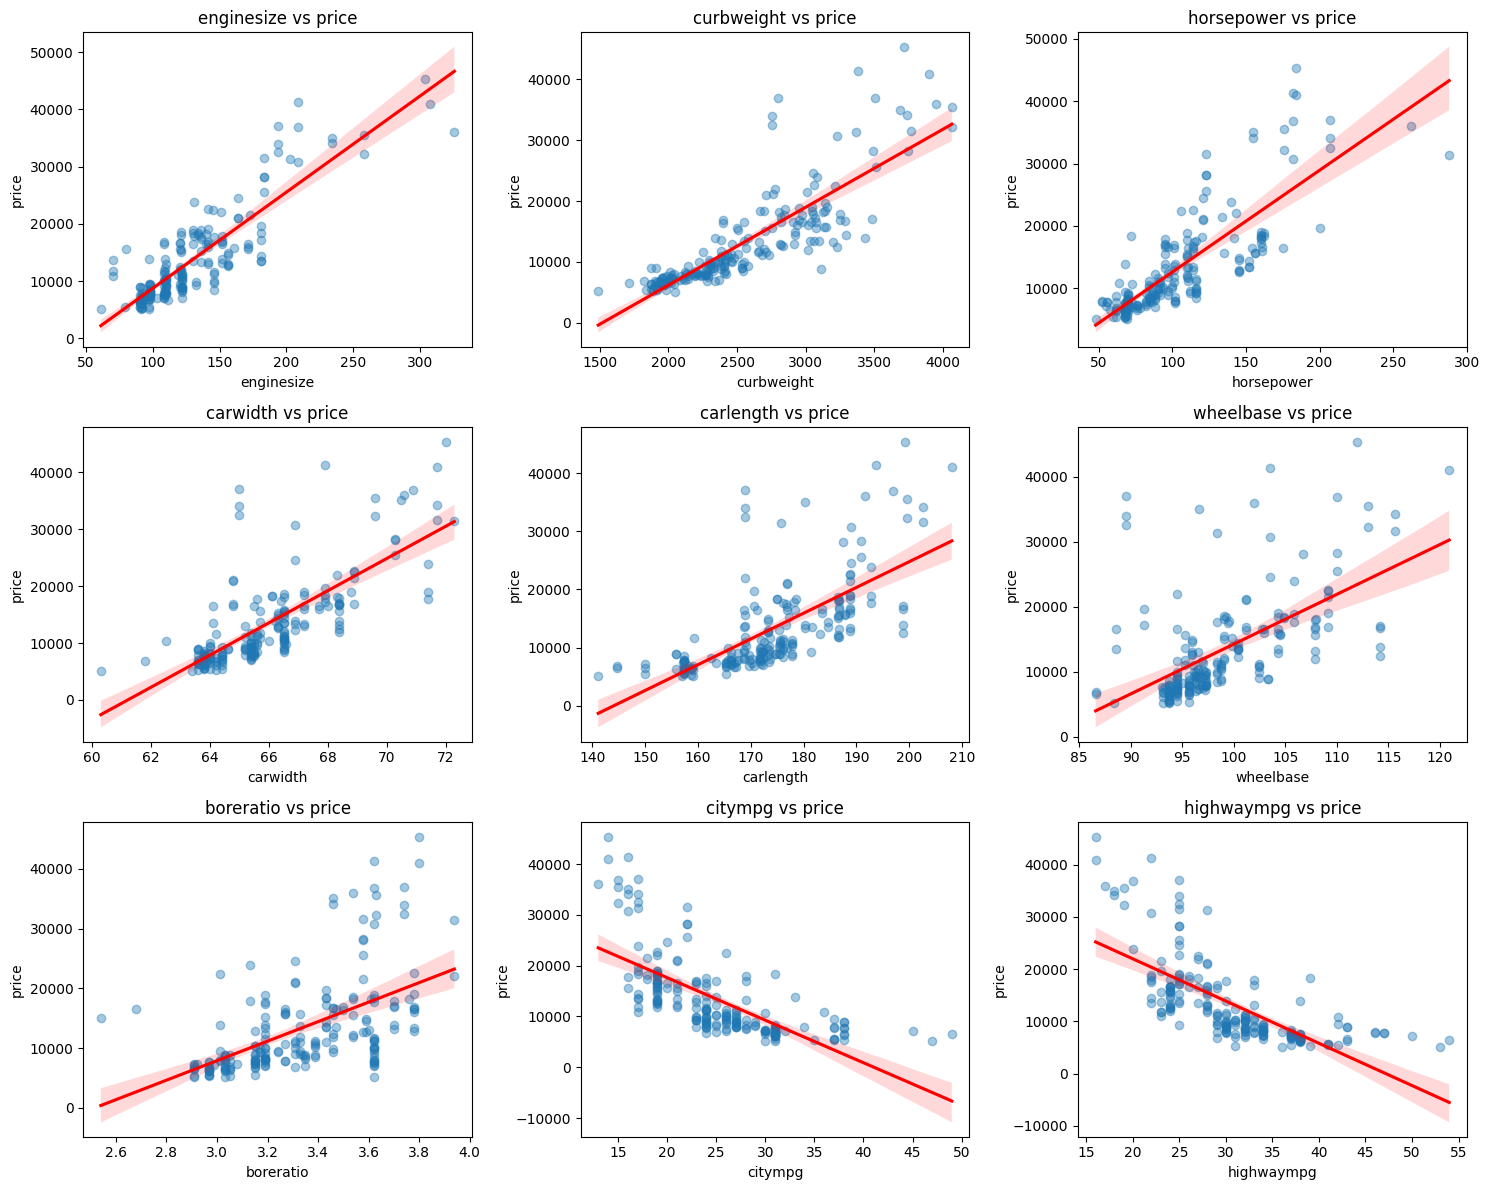

In [ ]:
# ── Numeric features vs price (scatterplots)
num_features = ['enginesize', 'curbweight', 'horsepower', 'carwidth', 'carlength', 'wheelbase', 'boreratio', 'citympg', 'highwaympg']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten() # turn 2D grid into a flat list of 9 axes

for i, col in enumerate(num_features):
    sns.regplot(x=car[col], y=car['price'], ax=axes[i], scatter_kws={'alpha': 0.4},
                line_kws={'color': 'red'}) # red trend line
    axes[i].set_title(f'{col} vs price')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3068/90785005.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.index, y=avg_price.values, palette='viridis')


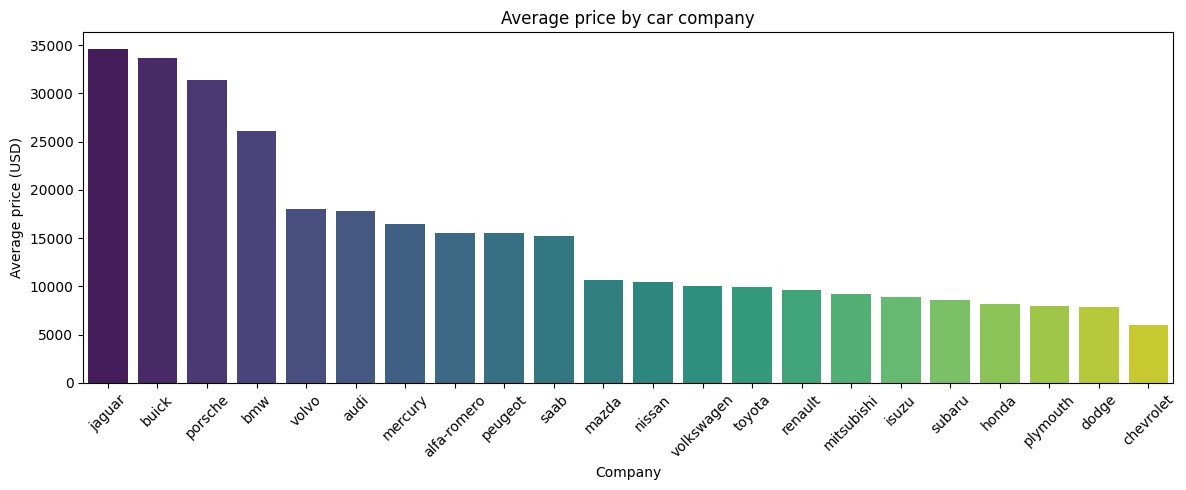

carCompany
jaguar         34600.0
buick          33647.0
porsche        31400.0
bmw            26119.0
volvo          18063.0
audi           17859.0
mercury        16503.0
alfa-romero    15498.0
peugeot        15489.0
saab           15223.0
mazda          10653.0
nissan         10416.0
volkswagen     10078.0
toyota          9886.0
renault         9595.0
mitsubishi      9240.0
isuzu           8916.0
subaru          8541.0
honda           8185.0
plymouth        7963.0
dodge           7875.0
chevrolet       6007.0


In [ ]:
#  Average price by car company
avg_price = (car.groupby('carCompany')['price']
               .mean()
               .sort_values(ascending=False))

plt.figure(figsize=(12, 5))
sns.barplot(x=avg_price.index, y=avg_price.values, palette='viridis')
plt.title('Average price by car company')
plt.xlabel('Company')
plt.ylabel('Average price (USD)')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Print the numbers too
print(avg_price.round(0).to_string())

### From above it is observed that carCompany is a strong predictor — average prices range from USD 6,000 (chevrolet) to USD 32,000 (jaguar), confirming brand has a major impact on pricing

## EDA Key Findings

**Target variable (price):**
- Right-skewed distribution; median ~$10,295, mean ~$13,277
- Range: $5,118 to $45,400
- High-value outliers are genuine luxury cars — retained in dataset

**Strongest numeric predictors (correlation > 0.80):**
- enginesize (0.87), curbweight (0.83), horsepower (0.81), carwidth (0.76)
- citympg (−0.69) and highwaympg (−0.70) are negatively correlated

**Categorical insights:**
- rwd (rear-wheel drive) cars are significantly more expensive than fwd
- Turbo aspiration cars cost more than standard
- 12-cylinder cars are far pricier than 4-cylinder
- Luxury brands (jaguar, porsche, bmw) command highest prices

**Multicollinearity risk:**
- enginesize, curbweight, horsepower, citympg and highwaympg are
  highly correlated with each other — this will be handled in
  model building using VIF analysis

In [ ]:
import pandas as pd
# List all categorical (text) columns that need dummy encoding
cat_cols = ['fueltype', 'aspiration', 'doornumber', 'carbody',
            'drivewheel', 'enginelocation', 'enginetype',
            'cylindernumber', 'fuelsystem', 'carCompany']

try:
    # pd.get_dummies() converts each category to 0/1 columns
    # drop_first=True removes one column per group to avoid
    # the dummy variable trap (perfect multicollinearity)
    df = pd.get_dummies(car, columns=cat_cols, drop_first=True)

    # Check: shape should now have many more columns
    print("Shape after dummies:", car.shape)
    print(f"Total columns now: {car.shape[1]}")
    print("\nFirst few column names:")
    print(list(car.columns[:10]))
except NameError as e:
    if "name 'car' is not defined" in str(e):
        print("Error: The 'car' DataFrame is not defined. Please ensure you have run all preceding cells that load and preprocess the car data.")
    else:
        raise e

Shape after dummies: (205, 25)
Total columns now: 25

First few column names:
['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth']
